In [1]:
from joblib import load
import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import presto_eokit
from presto_eokit import Presto
from presto_eokit.dataops.geo import set_geo_metadata

from dhi_mleo.inference import xr_predict

# Prepare data

We already stored the dataset with all the variables required to run the model and generate spatial predictions 

In [ ]:
ds = xr.open_dataset("../data/HOBE/dataset/features_dataset_20180701.nc")
ds

<xarray.Dataset> Size: 917MB
Dimensions:                          (time: 1, y: 1022, x: 1495)
Coordinates:
  * time                             (time) datetime64[ns] 8B 2018-07-01
  * y                                (y) float64 8kB 56.09 56.09 ... 55.86 55.86
  * x                                (x) float64 12kB 8.813 8.813 ... 9.157
Data variables: (12/76)
    20_irri_calc                     (time, y, x) float64 12MB ...
    20_RZD                           (time, y, x) float64 12MB ...
    20_RZSM_band1                    (time, y, x) float64 12MB ...
    20_RZSM_band2                    (time, y, x) float64 12MB ...
    20_RZSM_band3                    (time, y, x) float64 12MB ...
    DOY_UTC                          (time, y, x) float64 12MB ...
    ...                               ...
    TSEB_PT_20_LE_partition_gf_corr  (time, y, x) float64 12MB ...
    U                                (time, y, x) float64 12MB ...
    VZA                              (time, y, x) float64 12MB ...
    W_C                              (time, y, x) float64 12MB ...
    X_LAD                            (time, y, x) float64 12MB ...
    spatial_ref                      int32 4B ...

In [3]:
SM_S2_BANDS = {
    'REFL_band1': "B2",
    'REFL_band2': "B3",
    'REFL_band3': "B4",
    'REFL_band4': "B5",
    'REFL_band5': "B6",
    'REFL_band6': "B7",
    'REFL_band7': "B8A",
    'REFL_band8': "B11",
    'REFL_band9': "B12"
}
ds = ds.rename(SM_S2_BANDS)

# add derived variables
ds['weighted_sm'] = (ds['20_RZSM_band1'] + ds['20_RZSM_band2']) / 2

ds['NDVI'] = (ds["B8A"] - ds["B4"]) / (ds["B8A"] + ds["B4"])
ds['MNDWI'] = (ds["B3"] - ds["B11"]) / (ds["B3"] + ds["B11"])
ds['NMDI'] = (ds["B8A"] - (ds["B11"] - ds["B12"])) / (ds["B8A"] + (ds["B11"] - ds["B12"]))
ds["PSRI"] = (ds["B4"] - ds["B2"]) / ds["B8A"]
ds["VARI_red_edge"] = (ds["B5"] - (1.7 * ds["B4"]) + (0.7 * ds["B2"])) / (ds["B5"] + (2.3 * ds["B4"]) - (1.3 * ds["B2"]))
ds["BSI"] = ((ds["B11"] + ds["B4"]) - (ds["B8A"] + ds["B2"])) / ((ds["B11"] + ds["B4"]) + (ds["B8A"] + ds["B2"]))

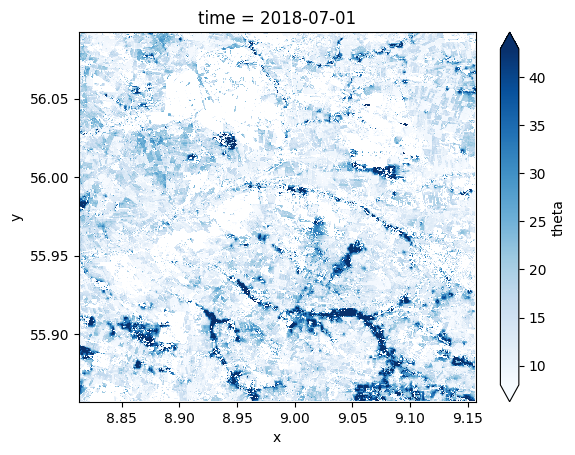

In [4]:
ds["weighted_sm"].sel(time="2018-07-01").plot(robust=True, cmap="Blues")

In [5]:
# lets add a dummy variable for month
import numpy as np
month = 7  
ds["Month"] = xr.DataArray(np.full(ds["B2"].shape, month), dims=ds["B2"].dims)

In [6]:
# make sure to set the crs if not already set
ds.rio.write_crs("EPSG:4326", inplace=True)
ds.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

# Generate the Embeddings

In [7]:
s2_da = ds.sel(time="2018-07-01")[[*SM_S2_BANDS.values()]].to_array(dim="band")
s2_da

<xarray.DataArray (band: 9, y: 1022, x: 1495)> Size: 110MB
array([[[ 368.6505127 ,  360.54302979,  327.50787354, ...,
          282.59573364,  265.95013428,  258.64248657],
        [ 412.75473022,  398.68096924,  344.31838989, ...,
          279.21282959,  269.01937866,  262.64624023],
        [ 374.95648193,  358.89874268,  295.96630859, ...,
          275.52258301,  264.13879395,  260.27478027],
        ...,
        [ 241.78668213,  232.46624756,  222.61444092, ...,
                   nan,           nan,           nan],
        [ 226.19569397,  226.51342773,  252.90995789, ...,
                   nan,           nan,           nan],
        [ 226.48017883,  235.25790405,  253.89990234, ...,
                   nan,           nan,           nan]],

       [[ 710.16107178,  693.27276611,  620.69775391, ...,
          522.32574463,  507.58383179,  491.32192993],
        [ 760.99847412,  732.32788086,  617.8503418 , ...,
          524.28216553,  505.44384766,  487.95376587],
        [ 695.06506348,  658.34820557,  516.72930908, ...,
          504.98291016,  494.27896118,  491.        ],
...
                   nan,           nan,           nan],
        [1511.69396973, 1489.8001709 , 1527.54821777, ...,
                   nan,           nan,           nan],
        [1523.35498047, 1539.67578125, 1576.56494141, ...,
                   nan,           nan,           nan]],

       [[ 743.17663574,  743.66290283,  752.27508545, ...,
          985.77368164,  997.65240479, 1016.57922363],
        [ 820.28515625,  819.45294189,  825.97540283, ...,
          979.94464111,  959.15783691,  987.5916748 ],
        [ 827.03277588,  820.36022949,  802.04675293, ...,
         1001.79553223,  937.73168945,  947.25042725],
        ...,
        [ 767.62860107,  729.39611816,  650.15460205, ...,
                   nan,           nan,           nan],
        [ 718.06848145,  707.17144775,  763.07263184, ...,
                   nan,           nan,           nan],
        [ 716.17022705,  764.00036621,  812.86486816, ...,
                   nan,           nan,           nan]]],
      shape=(9, 1022, 1495))
Coordinates:
  * band         (band) object 72B 'B2' 'B3' 'B4' 'B5' ... 'B8A' 'B11' 'B12'
  * y            (y) float64 8kB 56.09 56.09 56.09 56.09 ... 55.86 55.86 55.86
  * x            (x) float64 12kB 8.813 8.813 8.813 8.814 ... 9.156 9.156 9.157
    spatial_ref  int64 8B 0
    time         datetime64[ns] 8B 2018-07-01

In [8]:
device = "cpu" #"cuda" if torch.cuda.is_available() else "cpu"
model = Presto.load_pretrained(device)
model.to(device)
model.eval()  

Presto(
  (encoder): Encoder(
    (eo_patch_embed): ModuleDict(
      (S1): Linear(in_features=2, out_features=128, bias=True)
      (S2_RGB): Linear(in_features=3, out_features=128, bias=True)
      (S2_Red_Edge): Linear(in_features=3, out_features=128, bias=True)
      (S2_NIR_10m): Linear(in_features=1, out_features=128, bias=True)
      (S2_NIR_20m): Linear(in_features=1, out_features=128, bias=True)
      (S2_SWIR): Linear(in_features=2, out_features=128, bias=True)
      (ERA5): Linear(in_features=2, out_features=128, bias=True)
      (SRTM): Linear(in_features=2, out_features=128, bias=True)
      (NDVI): Linear(in_features=1, out_features=128, bias=True)
    )
    (dw_embed): Embedding(10, 128)
    (latlon_embed): Linear(in_features=3, out_features=128, bias=True)
    (blocks): ModuleList(
      (0-1): 2 x Block(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)

In [9]:
band_config = {"s2": [*SM_S2_BANDS.values()]}

embeds = presto_eokit.generate_embeddings(
    da=s2_da,
    model=model,
    band_configs=band_config,
    month=7, # S2 data is from July 
    timestep_dim=1,
    device=device, 
    batch_size=1024*12,
    spatial_dims=("y", "x"),
    band_dim="band",
)

Encoding: 100%|██████████| 125/125 [01:42<00:00,  1.21it/s]


In [10]:
embeds

<xarray.DataArray 'embeds' (embed: 128, y: 1022, x: 1495)> Size: 782MB
array([[[ 4.4402862e-01,  4.1137844e-01,  2.9124075e-01, ...,
          9.7815625e-02,  6.8955839e-02,  9.0993643e-02],
        [ 5.3462696e-01,  4.9195087e-01,  3.2768387e-01, ...,
          8.9714333e-02,  6.1276764e-02,  8.8810176e-02],
        [ 4.5629746e-01,  4.1338277e-01,  2.1595977e-01, ...,
          1.3469905e-01,  7.7219725e-02,  5.8722734e-02],
        ...,
        [ 1.2351681e-01,  6.4410813e-02, -5.4497197e-02, ...,
                    nan,            nan,            nan],
        [ 2.8465748e-02, -4.9431622e-04,  1.0112512e-01, ...,
                    nan,            nan,            nan],
        [-6.0729682e-03,  5.1262751e-02,  1.6287774e-01, ...,
                    nan,            nan,            nan]],

       [[-2.9440417e+00, -3.0385625e+00, -3.3807378e+00, ...,
         -4.0370488e+00, -4.1639171e+00, -4.1250086e+00],
        [-2.7550776e+00, -2.8867853e+00, -3.4276984e+00, ...,
         -4.0708876e+00, -4.1698351e+00, -4.1463246e+00],
        [-2.9308569e+00, -3.1115489e+00, -3.7562482e+00, ...,
         -4.0050573e+00, -4.1311026e+00, -4.1800103e+00],
...
                    nan,            nan,            nan],
        [-2.7690125e-01, -2.8562027e-01, -2.6284128e-01, ...,
                    nan,            nan,            nan],
        [-2.7252477e-01, -2.6569775e-01, -2.3747154e-01, ...,
                    nan,            nan,            nan]],

       [[-4.2987055e-01, -4.0229723e-01, -3.0418155e-01, ...,
         -4.5833138e-01, -4.8208132e-01, -4.6910074e-01],
        [-5.1477981e-01, -4.6242526e-01, -2.9539731e-01, ...,
         -4.5298326e-01, -4.5712474e-01, -4.5086759e-01],
        [-3.7770474e-01, -3.2333773e-01, -1.9738832e-01, ...,
         -4.3334004e-01, -4.2655373e-01, -4.4852990e-01],
        ...,
        [-2.4277259e-01, -2.6927060e-01, -2.7883750e-01, ...,
                    nan,            nan,            nan],
        [-2.7030450e-01, -2.8801730e-01, -2.8064543e-01, ...,
                    nan,            nan,            nan],
        [-2.8150260e-01, -2.7876267e-01, -2.4572589e-01, ...,
                    nan,            nan,            nan]]],
      shape=(128, 1022, 1495), dtype=float32)
Coordinates:
  * embed        (embed) int64 1kB 1 2 3 4 5 6 7 ... 122 123 124 125 126 127 128
  * y            (y) float64 8kB 56.09 56.09 56.09 56.09 ... 55.86 55.86 55.86
  * x            (x) float64 12kB 8.813 8.813 8.813 8.814 ... 9.156 9.156 9.157
    spatial_ref  int64 8B 0

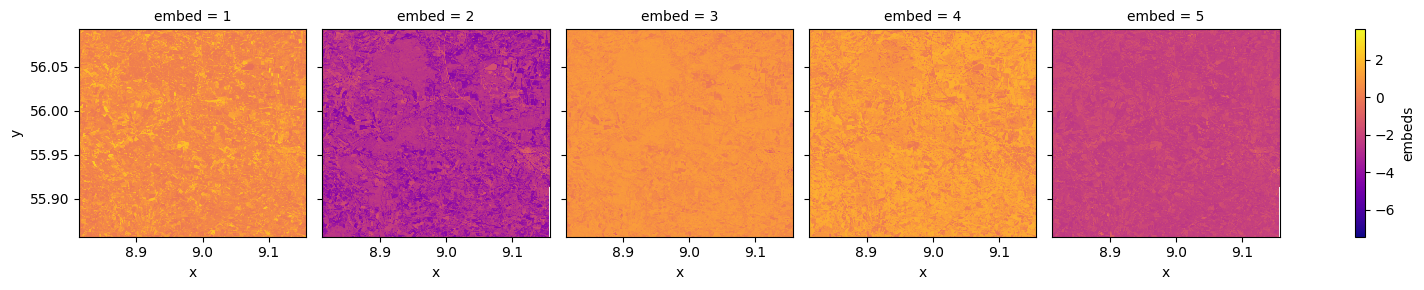

In [11]:
vmin = float(embeds.min())
vmax = float(embeds.max())

subset = embeds.sel(embed=[1, 2, 3, 4, 5])
subset.plot.imshow(
    col="embed",        
    cmap="plasma",
    vmin=vmin,
    vmax=vmax,
    robust=True   
)
plt.show()

In [12]:
# you could select any 3 embeddings channels
rgb_channels = [115,  83,  39] #np.random.choice(embeds.embed.values, size=3, replace=False)
rgb_da = embeds.sel(embed=rgb_channels)
rgb_da_norm = (rgb_da - rgb_da.min(dim=("y","x"))) / (rgb_da.max(dim=("y","x")) - rgb_da.min(dim=("y","x"))) # normalize to 0-1

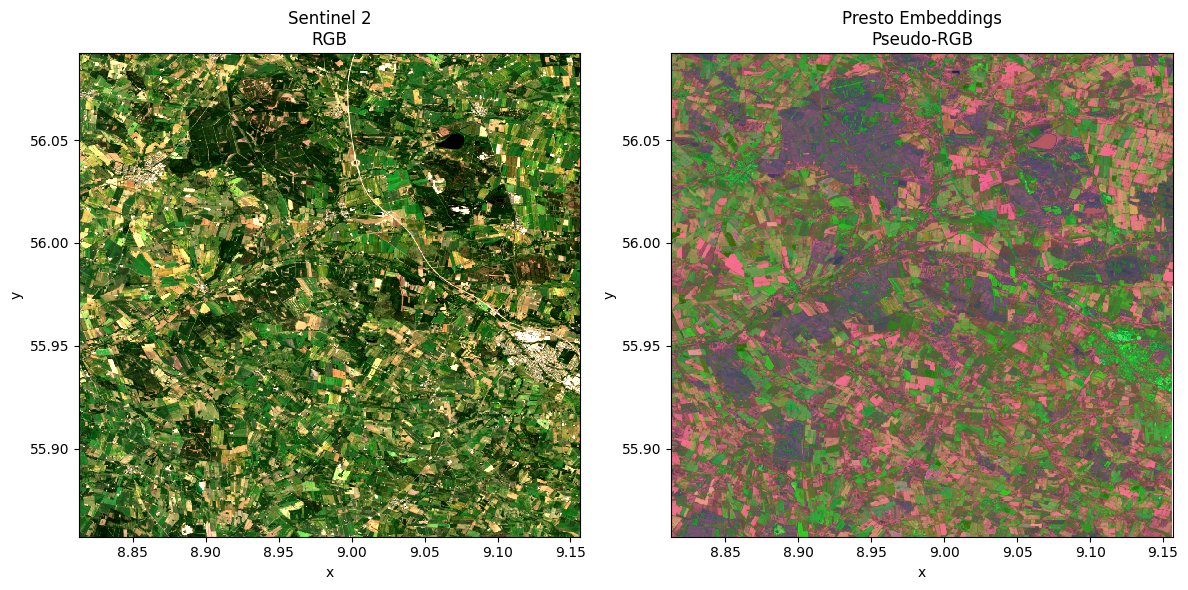

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

s2_rgb = s2_da.sel(dict(band=["B4", "B3", "B2"]))
s2_rgb.plot.imshow(robust=True, ax=axes[0])
axes[0].set_title("Sentinel 2\nRGB")

rgb_da_norm.plot.imshow(robust=False, ax=axes[1])
axes[1].set_title("Presto Embeddings\nPseudo-RGB")

plt.tight_layout()
plt.show()

# Model Prediction/Inference

In [ ]:
trained_model = load("../data/HOBE/models/presto_histgb_model.joblib")
trained_model

,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",300
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide ` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categorical.py`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 

In [15]:
extra_features = [
    'ELEV', 
    'ETref',
    'weighted_sm',
    '20_RZSM_band1',
    '20_RZSM_band2',
    'Month',
    'DOY_UTC'
]
len(extra_features)

7

In [16]:
extra_ds = ds.sel(time="2018-07-01")[extra_features].to_array(dim="band")
extra_ds

<xarray.DataArray (band: 7, y: 1022, x: 1495)> Size: 86MB
array([[[ 46.        ,  46.        ,  46.        , ...,  62.        ,
          62.        ,  62.        ],
        [ 46.        ,  46.        ,  46.        , ...,  62.        ,
          62.        ,  62.        ],
        [ 46.        ,  46.        ,  46.        , ...,  62.        ,
          62.        ,  62.        ],
        ...,
        [ 26.        ,  26.        ,  26.        , ...,          nan,
                  nan,          nan],
        [ 26.        ,  26.        ,  26.        , ...,          nan,
                  nan,          nan],
        [ 26.        ,  26.        ,  26.        , ...,          nan,
                  nan,          nan]],

       [[  5.14928293,   5.14928293,   5.14928293, ...,   5.03181458,
           5.03181458,   5.03181458],
        [  5.14928293,   5.14928293,   5.14928293, ...,   5.03181458,
           5.03181458,   5.03181458],
        [  5.14928293,   5.14928293,   5.14928293, ...,   5.03181458,
           5.03181458,   5.03181458],
...
        [  7.        ,   7.        ,   7.        , ...,   7.        ,
           7.        ,   7.        ],
        [  7.        ,   7.        ,   7.        , ...,   7.        ,
           7.        ,   7.        ],
        [  7.        ,   7.        ,   7.        , ...,   7.        ,
           7.        ,   7.        ]],

       [[182.        , 182.        , 182.        , ..., 182.        ,
         182.        , 182.        ],
        [182.        , 182.        , 182.        , ..., 182.        ,
         182.        , 182.        ],
        [182.        , 182.        , 182.        , ..., 182.        ,
         182.        , 182.        ],
        ...,
        [182.        , 182.        , 182.        , ...,          nan,
                  nan,          nan],
        [182.        , 182.        , 182.        , ...,          nan,
                  nan,          nan],
        [182.        , 182.        , 182.        , ...,          nan,
                  nan,          nan]]], shape=(7, 1022, 1495))
Coordinates:
  * band         (band) object 56B 'ELEV' 'ETref' ... 'Month' 'DOY_UTC'
  * y            (y) float64 8kB 56.09 56.09 56.09 56.09 ... 55.86 55.86 55.86
  * x            (x) float64 12kB 8.813 8.813 8.813 8.814 ... 9.156 9.156 9.157
    spatial_ref  int64 8B 0
    time         datetime64[ns] 8B 2018-07-01

- Since during the training with numpy the index start with 0 while the generated embeddings start with 1, we need to add 1 to the selected indices
- We need to stack the features in the same order as the trainig 

In [17]:
selected_embeddings =  [ i+1 for i in [16, 52, 108, 120]] 
ds_ard = xr.concat(
    [
        embeds.sel(dict(embed=selected_embeddings)).rename({'embed': 'band'}), 
        extra_ds], 
     dim="band"
)

In [18]:
ds_ard

<xarray.DataArray 'embeds' (band: 11, y: 1022, x: 1495)> Size: 134MB
array([[[-2.60093498e+00, -2.58479214e+00, -2.48109531e+00, ...,
         -2.46012950e+00, -2.48400068e+00, -2.45709133e+00],
        [-2.63986135e+00, -2.62833524e+00, -2.51424932e+00, ...,
         -2.47112298e+00, -2.48017955e+00, -2.46285248e+00],
        [-2.57874894e+00, -2.56071258e+00, -2.42930961e+00, ...,
         -2.43873692e+00, -2.45937943e+00, -2.46672606e+00],
        ...,
        [-2.21493530e+00, -2.23013854e+00, -2.21747327e+00, ...,
                     nan,             nan,             nan],
        [-2.24585152e+00, -2.24409914e+00, -2.23937392e+00, ...,
                     nan,             nan,             nan],
        [-2.26037908e+00, -2.25845599e+00, -2.23556757e+00, ...,
                     nan,             nan,             nan]],

       [[-1.22977257e-01, -1.34268790e-01, -1.73519254e-01, ...,
         -1.69126064e-01, -1.70725912e-01, -1.65143386e-01],
        [-1.23079583e-01, -1.31945580e-01, -1.66371644e-01, ...,
         -1.69591010e-01, -1.68159887e-01, -1.60254046e-01],
        [-1.30255491e-01, -1.36599317e-01, -1.49693459e-01, ...,
         -1.60567015e-01, -1.62878692e-01, -1.68443158e-01],
...
          7.00000000e+00,  7.00000000e+00,  7.00000000e+00],
        [ 7.00000000e+00,  7.00000000e+00,  7.00000000e+00, ...,
          7.00000000e+00,  7.00000000e+00,  7.00000000e+00],
        [ 7.00000000e+00,  7.00000000e+00,  7.00000000e+00, ...,
          7.00000000e+00,  7.00000000e+00,  7.00000000e+00]],

       [[ 1.82000000e+02,  1.82000000e+02,  1.82000000e+02, ...,
          1.82000000e+02,  1.82000000e+02,  1.82000000e+02],
        [ 1.82000000e+02,  1.82000000e+02,  1.82000000e+02, ...,
          1.82000000e+02,  1.82000000e+02,  1.82000000e+02],
        [ 1.82000000e+02,  1.82000000e+02,  1.82000000e+02, ...,
          1.82000000e+02,  1.82000000e+02,  1.82000000e+02],
        ...,
        [ 1.82000000e+02,  1.82000000e+02,  1.82000000e+02, ...,
                     nan,             nan,             nan],
        [ 1.82000000e+02,  1.82000000e+02,  1.82000000e+02, ...,
                     nan,             nan,             nan],
        [ 1.82000000e+02,  1.82000000e+02,  1.82000000e+02, ...,
                     nan,             nan,             nan]]],
      shape=(11, 1022, 1495))
Coordinates:
  * band         (band) object 88B 17 53 109 ... 'Month' 'DOY_UTC'
  * y            (y) float64 8kB 56.09 56.09 56.09 56.09 ... 55.86 55.86 55.86
  * x            (x) float64 12kB 8.813 8.813 8.813 8.814 ... 9.156 9.156 9.157
    spatial_ref  int64 8B 0
    time         datetime64[ns] 8B 2018-07-01

In [19]:
ds_ard.band

<xarray.DataArray 'band' (band: 11)> Size: 88B
array([17, 53, 109, 121, 'ELEV', 'ETref', 'weighted_sm', '20_RZSM_band1',
       '20_RZSM_band2', 'Month', 'DOY_UTC'], dtype=object)
Coordinates:
  * band         (band) object 88B 17 53 109 ... 'Month' 'DOY_UTC'
    spatial_ref  int64 8B 0
    time         datetime64[ns] 8B 2018-07-01

In [20]:
da_pred = xr_predict(
    da=ds_ard,
    model=trained_model,
    feature_names=[*ds_ard.band.values],
    band_dim="band",    
    chunk_size=1012*1012,
    pred_name="SM_preds",
)
da_pred = set_geo_metadata(target=da_pred, source=ds_ard)

Predicting: 100%|██████████| 2/2 [00:10<00:00,  5.09s/it]


In [21]:
da_pred

<xarray.DataArray 'SM_preds' (y: 1022, x: 1495)> Size: 12MB
array([[12.34658869, 13.05775491, 12.75998191, ...,  6.44026845,
         6.60538972,  6.29351594],
       [12.7335933 , 11.89118701,  9.62859712, ...,  6.49277842,
         6.67824991,  6.34602591],
       [11.84274993, 13.407925  , 12.70829981, ...,  6.15395888,
         6.29351594,  6.34602591],
       ...,
       [12.97779182, 13.03013444, 12.18946412, ..., 19.60734799,
        19.60734799, 19.60734799],
       [12.26859689, 12.62485758, 12.90318617, ..., 19.60734799,
        19.60734799, 19.60734799],
       [12.1090993 , 12.99420941, 13.1423246 , ..., 19.60734799,
        19.60734799, 19.60734799]], shape=(1022, 1495))
Coordinates:
  * y            (y) float64 8kB 56.09 56.09 56.09 56.09 ... 55.86 55.86 55.86
  * x            (x) float64 12kB 8.813 8.813 8.813 8.814 ... 9.156 9.156 9.157
    spatial_ref  int64 8B 0

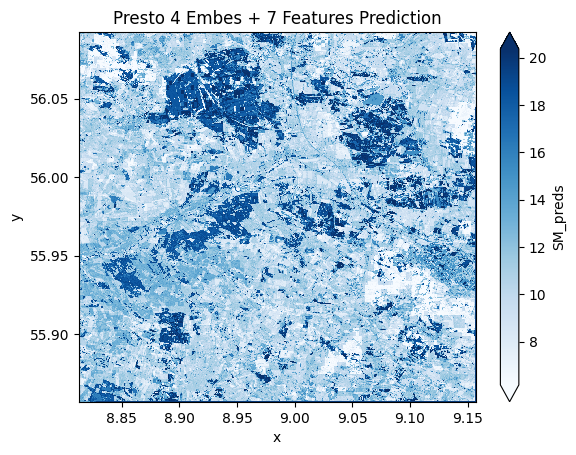

In [22]:
p = da_pred.plot(cmap="Blues", robust=True)
plt.title("Presto 4 Embes + 7 Features Prediction")
plt.show()

In [ ]:
import os

os.makedirs("../data/HOBE/preds", exist_ok=True)
da_pred.rio.to_raster("../data/HOBE/preds/presto_SM_predictions_20180701.tif")

# Compare predictions results

In this section we will compare our prediction results with the prediction genereated in with *ML_HOBE* notebook. 

In [ ]:
s2_da_pred = xr.open_dataarray("../data/HOBE/preds/SM_predictions_20180701.tif")
presto_da_pred = xr.open_dataarray("../data/HOBE/preds/presto_SM_predictions_20180701.tif")

In [25]:
a = presto_da_pred.sel(band=1).squeeze(drop=True)     # (y, x)
b = s2_da_pred.sel(band=1).squeeze(drop=True)         # (y, x)
merged = xr.concat([a, b], dim="band")
merged = merged.assign_coords(band=("band", ["presto_preds", "s2_preds"]))
merged = merged.transpose("band", "y", "x")

In [26]:
merged

<xarray.DataArray 'band_data' (band: 2, y: 1022, x: 1495)> Size: 24MB
array([[[12.34658869, 13.05775491, 12.75998191, ...,  6.44026845,
          6.60538972,  6.29351594],
        [12.7335933 , 11.89118701,  9.62859712, ...,  6.49277842,
          6.67824991,  6.34602591],
        [11.84274993, 13.407925  , 12.70829981, ...,  6.15395888,
          6.29351594,  6.34602591],
        ...,
        [12.97779182, 13.03013444, 12.18946412, ..., 19.60734799,
         19.60734799, 19.60734799],
        [12.26859689, 12.62485758, 12.90318617, ..., 19.60734799,
         19.60734799, 19.60734799],
        [12.1090993 , 12.99420941, 13.1423246 , ..., 19.60734799,
         19.60734799, 19.60734799]],

       [[13.86316049, 12.7999402 , 12.09258658, ...,  7.79119909,
          8.28197983,  7.9968284 ],
        [13.20699061, 13.03973851, 11.82653692, ...,  8.74278663,
          8.56872803,  8.50365555],
        [13.11709329, 13.10519543, 11.28175661, ...,  8.28695837,
          8.05933815,  7.92832357],
        ...,
        [13.22999873, 13.25926423, 12.70058997, ..., 15.24009367,
         15.24009367, 15.24009367],
        [12.67606242, 12.9914697 , 13.08297945, ..., 15.24009367,
         15.24009367, 15.24009367],
        [12.7148776 , 13.37327493, 13.27879791, ..., 15.24009367,
         15.24009367, 15.24009367]]], shape=(2, 1022, 1495))
Coordinates:
  * band         (band) <U12 96B 'presto_preds' 's2_preds'
  * y            (y) float64 8kB 56.09 56.09 56.09 56.09 ... 55.86 55.86 55.86
  * x            (x) float64 12kB 8.813 8.813 8.813 8.814 ... 9.156 9.156 9.157
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    long_name:      SM_preds

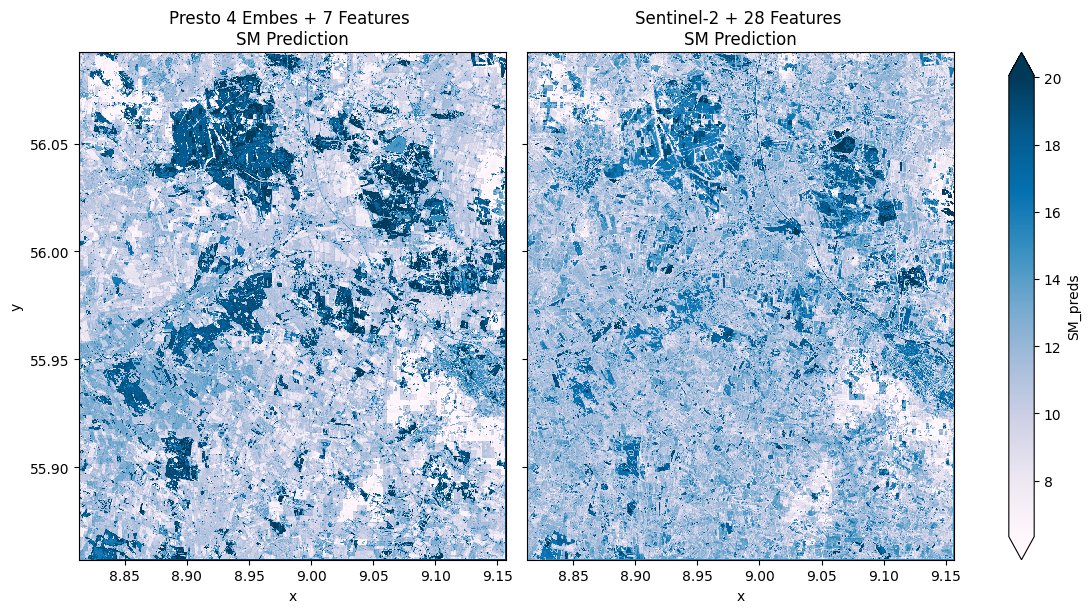

In [27]:
p = merged.plot(
    col="band",
    robust=True,
    cmap="PuBu",
    figsize=(12, 6) 
)
p.axs[0, 0].set_title("Presto 4 Embes + 7 Features \nSM Prediction")
p.axs[0, 1].set_title("Sentinel-2 + 28 Features \nSM Prediction")
plt.show()

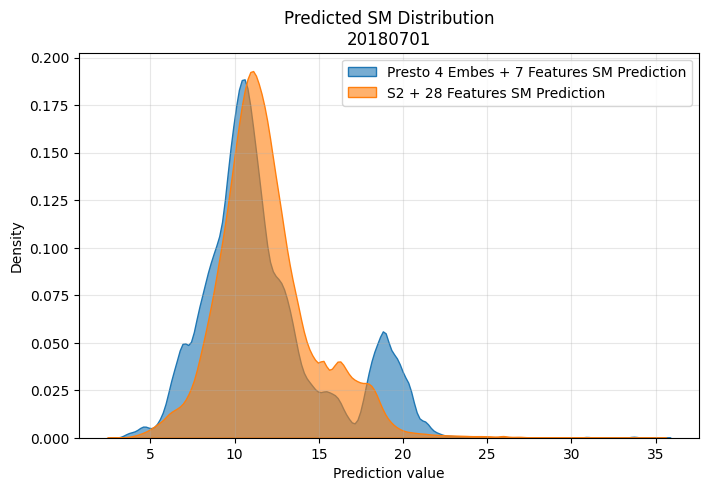

In [28]:
plt.figure(figsize=(8, 5))

sns.kdeplot(
    presto_da_pred.values.ravel(),
    fill=True,
    label="Presto 4 Embes + 7 Features SM Prediction",
    color="tab:blue",
    alpha=0.6
)

sns.kdeplot(
    s2_da_pred.values.ravel(),
    fill=True,
    label="S2 + 28 Features SM Prediction",
    color="tab:orange",
    alpha=0.6
)

plt.legend()
plt.xlabel("Prediction value")
plt.ylabel("Density")
plt.title("Predicted SM Distribution\n20180701")
plt.grid(alpha=0.3)
plt.show()